# Telco Customer Churn — Exploratory Data Analysis

**Dataset:** 

IBM Telco Customer Churn

---

**Goal:**

Understand the data, identify patterns, and decide which features to keep for the model

---

**Target Variable:**

Churn (Yes/No)

---

In [185]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Reading CSV File

In [4]:
df = pd.read_csv(r'..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
rows, cols = df.shape
total_fields = df.size
col_list = df.columns.tolist()
print(f'''
Rows          : {rows}
Cols          : {cols}
Total fields  : {total_fields}
Columns       : {col_list}
''')


Rows          : 7043
Cols          : 21
Total fields  : 147903
Columns       : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']



In [200]:
# lowering case of column name
df.columns = df.columns.str.lower()

In [87]:
# checking for nulls 
nulls = df.isna().sum().sum()
print(f"Null count : {nulls}")

Null count : 0


In [88]:
# checking for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate count : {duplicates}")


Duplicate count : 0


In [91]:
# checking for dtypes and values 
for i in col_list:
    print(f'''
Column    : {i}
Data type : {df[i].dtype}
values    : {df[i].head(5).to_list()} 
''')


Column    : customerID
Data type : object
values    : ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU'] 


Column    : gender
Data type : object
values    : ['Female', 'Male', 'Male', 'Male', 'Female'] 


Column    : SeniorCitizen
Data type : int64
values    : [0, 0, 0, 0, 0] 


Column    : Partner
Data type : object
values    : ['Yes', 'No', 'No', 'No', 'No'] 


Column    : Dependents
Data type : object
values    : ['No', 'No', 'No', 'No', 'No'] 


Column    : tenure
Data type : int64
values    : [1, 34, 2, 45, 2] 


Column    : PhoneService
Data type : object
values    : ['No', 'Yes', 'Yes', 'No', 'Yes'] 


Column    : MultipleLines
Data type : object
values    : ['No phone service', 'No', 'No', 'No phone service', 'No'] 


Column    : InternetService
Data type : object
values    : ['DSL', 'DSL', 'DSL', 'DSL', 'Fiber optic'] 


Column    : OnlineSecurity
Data type : object
values    : ['No', 'Yes', 'Yes', 'Yes', 'No'] 


Column    : OnlineBackup
Data type : obje

In [ ]:
# checking TotalCharges
try : 
    df['totalcharges'].astype(float)
except Exception as e: 
    print(e)

could not convert string to float: ' '


In [ ]:
# checking number of spaces 
df['totalcharges'].tolist().count(' ')

0

In [ ]:
# replacing the spaces with nan 
df['totalcharges'] = df['totalcharges'].replace(r'^\s*$', np.nan, regex=True)

In [198]:
# droping nulls, making less 0.0015% of data 
df = df.dropna()
print(f'''
Previous Shape : {rows, cols}
New Shape : {df.shape}
''')
rows, cols = df.shape
# converting to correct data 
df['totalcharges'] = df['totalcharges'].astype(float)


Previous Shape : (7032, 21)
New Shape : (7032, 21)



In [145]:
# checking again 
df.select_dtypes([int, float]).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


Churned     : (1869, 26.58)
Not Churned : (5163, 73.42)



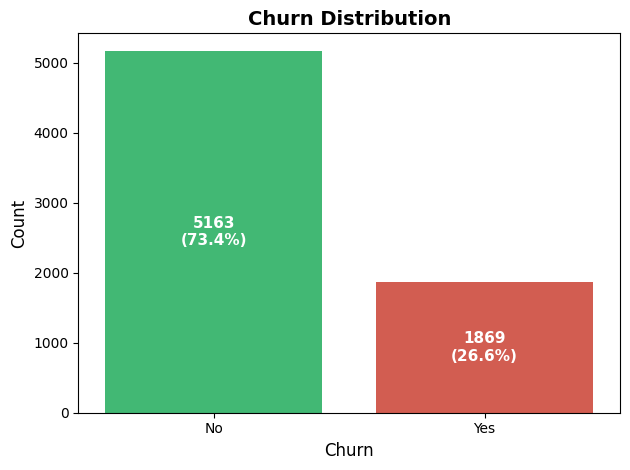

In [203]:
# Target variable
x, y = df['churn'].value_counts()
print(f'''
Churned     : {y, (round(y/rows*100, 2))}
Not Churned : {x, (round(x/rows*100, 2))}
''')

ax = sns.countplot(data=df, x='churn', hue='churn', 
                   palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, 
                   legend=False)

total = len(df)
for bar in ax.patches:
    count = int(bar.get_height())
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x center
        bar.get_height() / 2,               # y middle of bar
        f'{count}\n({pct:.1f}%)',
        ha='center', va='center',           # center both ways
        fontsize=11, color='white', fontweight='bold'
    )

plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()


Male   : (3549, 50.47)
Female : (3483, 49.53)



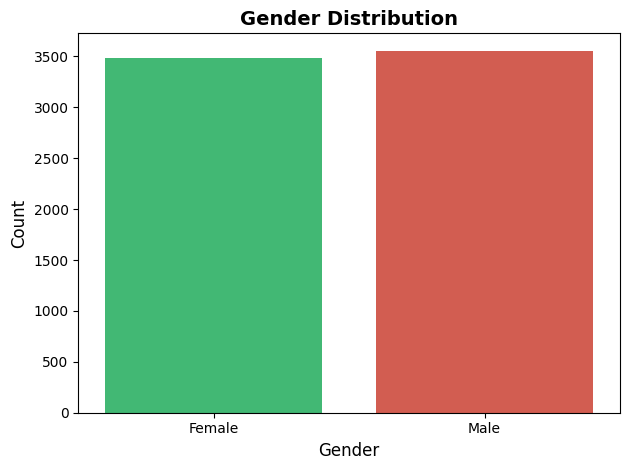

In [207]:
# gender 
male, female = df['gender'].value_counts()
print(f'''
Male   : {male, (round(male/rows*100, 2))}
Female : {female, (round(female/rows*100, 2))}
''')

x = sns.countplot(data=df, x='gender', hue='gender', 
                   palette={'Male': '#e74c3c', 'Female': '#2ecc71'}, 
                   legend=False)

total = len(df)
for bar in ax.patches:
    count = int(bar.get_height())
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x center
        bar.get_height() / 2,               # y middle of bar
        f'{count}\n({pct:.1f}%)',
        ha='center', va='center',           # center both ways
        fontsize=11, color='white', fontweight='bold'
    )

plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()